In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from shot_curve_util import fillingCurvePoints
from DOE import sample_doe, extend_doe

In [27]:
filling_constants = fillingCurvePoints(f_liq_sol=0.92, rho_solid=2.63e3)
(filling_constants.s_m_100*1e3).round(), (filling_constants.s_ma*1e3).round(), (filling_constants.s_ffin*1e3).round()

(np.float64(441.0), np.float64(462.0), np.float64(676.0))

In [28]:
def t_kr(vc: float, delay: float = -0.55, first_phase_type: str = "Buhler", filling_obj: fillingCurvePoints = filling_constants) -> float:
    if "buhler" in first_phase_type.lower() or "buehler" in first_phase_type.lower():
        # (v_crit, s2, s3, v3, s4, v4, sbrake, vbrake, s_ffin)
        _, _, _, _, _, _, t_kr = filling_obj._buhler(filling_obj.s, filling_obj.d_M, filling_obj.fr, filling_obj.s_m_100, vc, v_initial=filling_obj.v_init)
        return t_kr - delay
    else:
        raise NotImplementedError()

In [29]:
# 1. Independent Variables Config (Direct mapping to discrete levels)
sampling_params = {
    # Slow Variables (Temperatures)
    "hf1":  {"type": "uniform", "min": 140, "max": 180, "step": 20, "htc": True},
    "hm2": {"type": "uniform", "min": 110, "max": 150, "step": 20, "htc": True},
    "metal": {"type": "uniform", "min": 675, "max": 715, "step": 20, "htc": True},

    # Free Variables
    "vcrit":    {"type": "uniform", "min": 0.3, "max": 0.55, "step": 0.05},
    "vI":    {"type": "uniform", "min": 2, "max": 3.6, "step": 0.1},
    # ---------------------------------------------------------------------------------------
    # to be discussed
    "sm100_s4":    {"type": "uniform", "min": 10, "max": 110, "step": 10},
    "v3_vI_vcrit":    {"type": "uniform", "min": 0.1, "max": 0.9, "step": 0.05},
    "s34_ratio":    {"type": "uniform", "min": 0.1, "max": 0.9, "step": 0.05},
    "s_brake":    {"type": "normal", "min": 690, "max": 705, "mean": 700, "step": 5},
    "vbrake":    {"type": "uniform", "min": 0.2, "max": 1., "step": 0.1},
    # ---------------------------------------------------------------------------------------
    "p0":     {"type": "uniform", "min": 250, "max": 500, "step": 50},
    "pvac":   {"type": "log-uniform", "min": 10, "max": 1000, "num_steps": 7},
    "sol_time": {"type": "uniform", "min": 3, "max": 6, "step": 1},
}

In [30]:
# 2. Initial Machine State
initial_machine_state = {
    "hf1": 160,
    "hm2": 130,
    "metal": 695
}

In [31]:
# 3. Dependent Variables Config (Extended later)
dependent_formulas = {
    # Constants
    "piston": 60,
    
    # Dependent Variables (using lambda functions applied to the dataframe)
    "hf2": lambda df: df["hf1"] + 20,
    "hf3": lambda df: df["hf1"],
    "f3": lambda df: df["hf1"] - 40,
    "f4": lambda df: df["hf1"] - 40,
    "hm3": lambda df: df["hm2"] - 10,
    "hm4": lambda df: df["hm2"] + 20,
    "m4": lambda df: df["hm2"] - 50,
    "s3": lambda df: (df["sm100_s4"]*df["s34_ratio"] + filling_constants.s_m_100*1e3).round(),
    "v3": lambda df: ((df["vI"] - df["vcrit"])*df["v3_vI_vcrit"] + df["vcrit"]).round(2),
    "s4": lambda df: (df["sm100_s4"] + filling_constants.s_m_100*1e3).round(),
    "t_trigger": lambda df: df["vcrit"].apply(t_kr).round(2),
}

In [32]:
# 4. Execution Pipeline
indep_doe = sample_doe(
    sampling_config=sampling_params, 
    initial_config=initial_machine_state, 
    n_groups=8, 
    samples_per_group=16, 
    seed=42, 
    default_sigma_level=2.
)

# Applying Dependent Formulas
extended_doe = extend_doe(indep_doe, dependent_formulas, ["sm100_s4", "v3_vI_vcrit", "s34_ratio"])

# Shift index to start at 1 for readability
extended_doe.index += 1

In [33]:
# visual check
extended_doe.head(20)

,Group_ID,hf1,hm2,metal,vcrit,vI,s_brake,vbrake,p0,pvac,...,hf3,f3,f4,hm3,hm4,m4,s3,v3,s4,t_trigger
1,1,160.0,130.0,695.0,0.40,3.3,705.0,0.8,400.0,464.0,...,160.0,120.0,120.0,120.0,150.0,80.0,473.0,0.69,531.0,2.65
2,1,160.0,130.0,695.0,0.45,2.1,695.0,0.5,250.0,46.0,...,160.0,120.0,120.0,120.0,150.0,80.0,455.0,1.61,461.0,2.43
3,1,160.0,130.0,695.0,0.55,3.0,695.0,1.0,350.0,22.0,...,160.0,120.0,120.0,120.0,150.0,80.0,486.0,1.29,501.0,2.10
4,1,160.0,130.0,695.0,0.30,2.6,700.0,0.3,500.0,100.0,...,160.0,120.0,120.0,120.0,150.0,80.0,456.0,1.57,491.0,3.30
5,1,160.0,130.0,695.0,0.30,2.9,705.0,0.9,300.0,10.0,...,160.0,120.0,120.0,120.0,150.0,80.0,443.0,2.12,451.0,3.30
6,1,160.0,130.0,695.0,0.55,2.5,700.0,0.2,500.0,215.0,...,160.0,120.0,120.0,120.0,150.0,80.0,529.0,1.43,551.0,2.10
7,1,160.0,130.0,695.0,0.50,3.6,695.0,0.7,450.0,1000.0,...,160.0,120.0,120.0,120.0,150.0,80.0,458.0,3.29,471.0,2.25
8,1,160.0,130.0,695.0,0.35,2.3,700.0,0.4,250.0,46.0,...,160.0,120.0,120.0,120.0,150.0,80.0,473.0,0.94,521.0,2.93
9,1,160.0,130.0,695.0,0.40,3.2,700.0,0.8,300.0,10.0,...,160.0,120.0,120.0,120.0,150.0,80.0,467.0,1.66,481.0,2.65
10,1,160.0,130.0,695.0,0.45,2.8,695.0,0.2,450.0,464.0,...,160.0,120.0,120.0,120.0,150.0,80.0,477.0,1.98,531.0,2.43


In [34]:
columns2print = ['Group_ID', 'vcrit', 's3', 'v3', 's4', 'vI', 's_brake', 'vbrake', 't_trigger', 'p0', 'pvac', 'sol_time', 'hf1', 'hm2', 'metal', 'piston', 'hf2', 'hf3', 'f3', 'f4', 'hm3', 'hm4', 'm4']

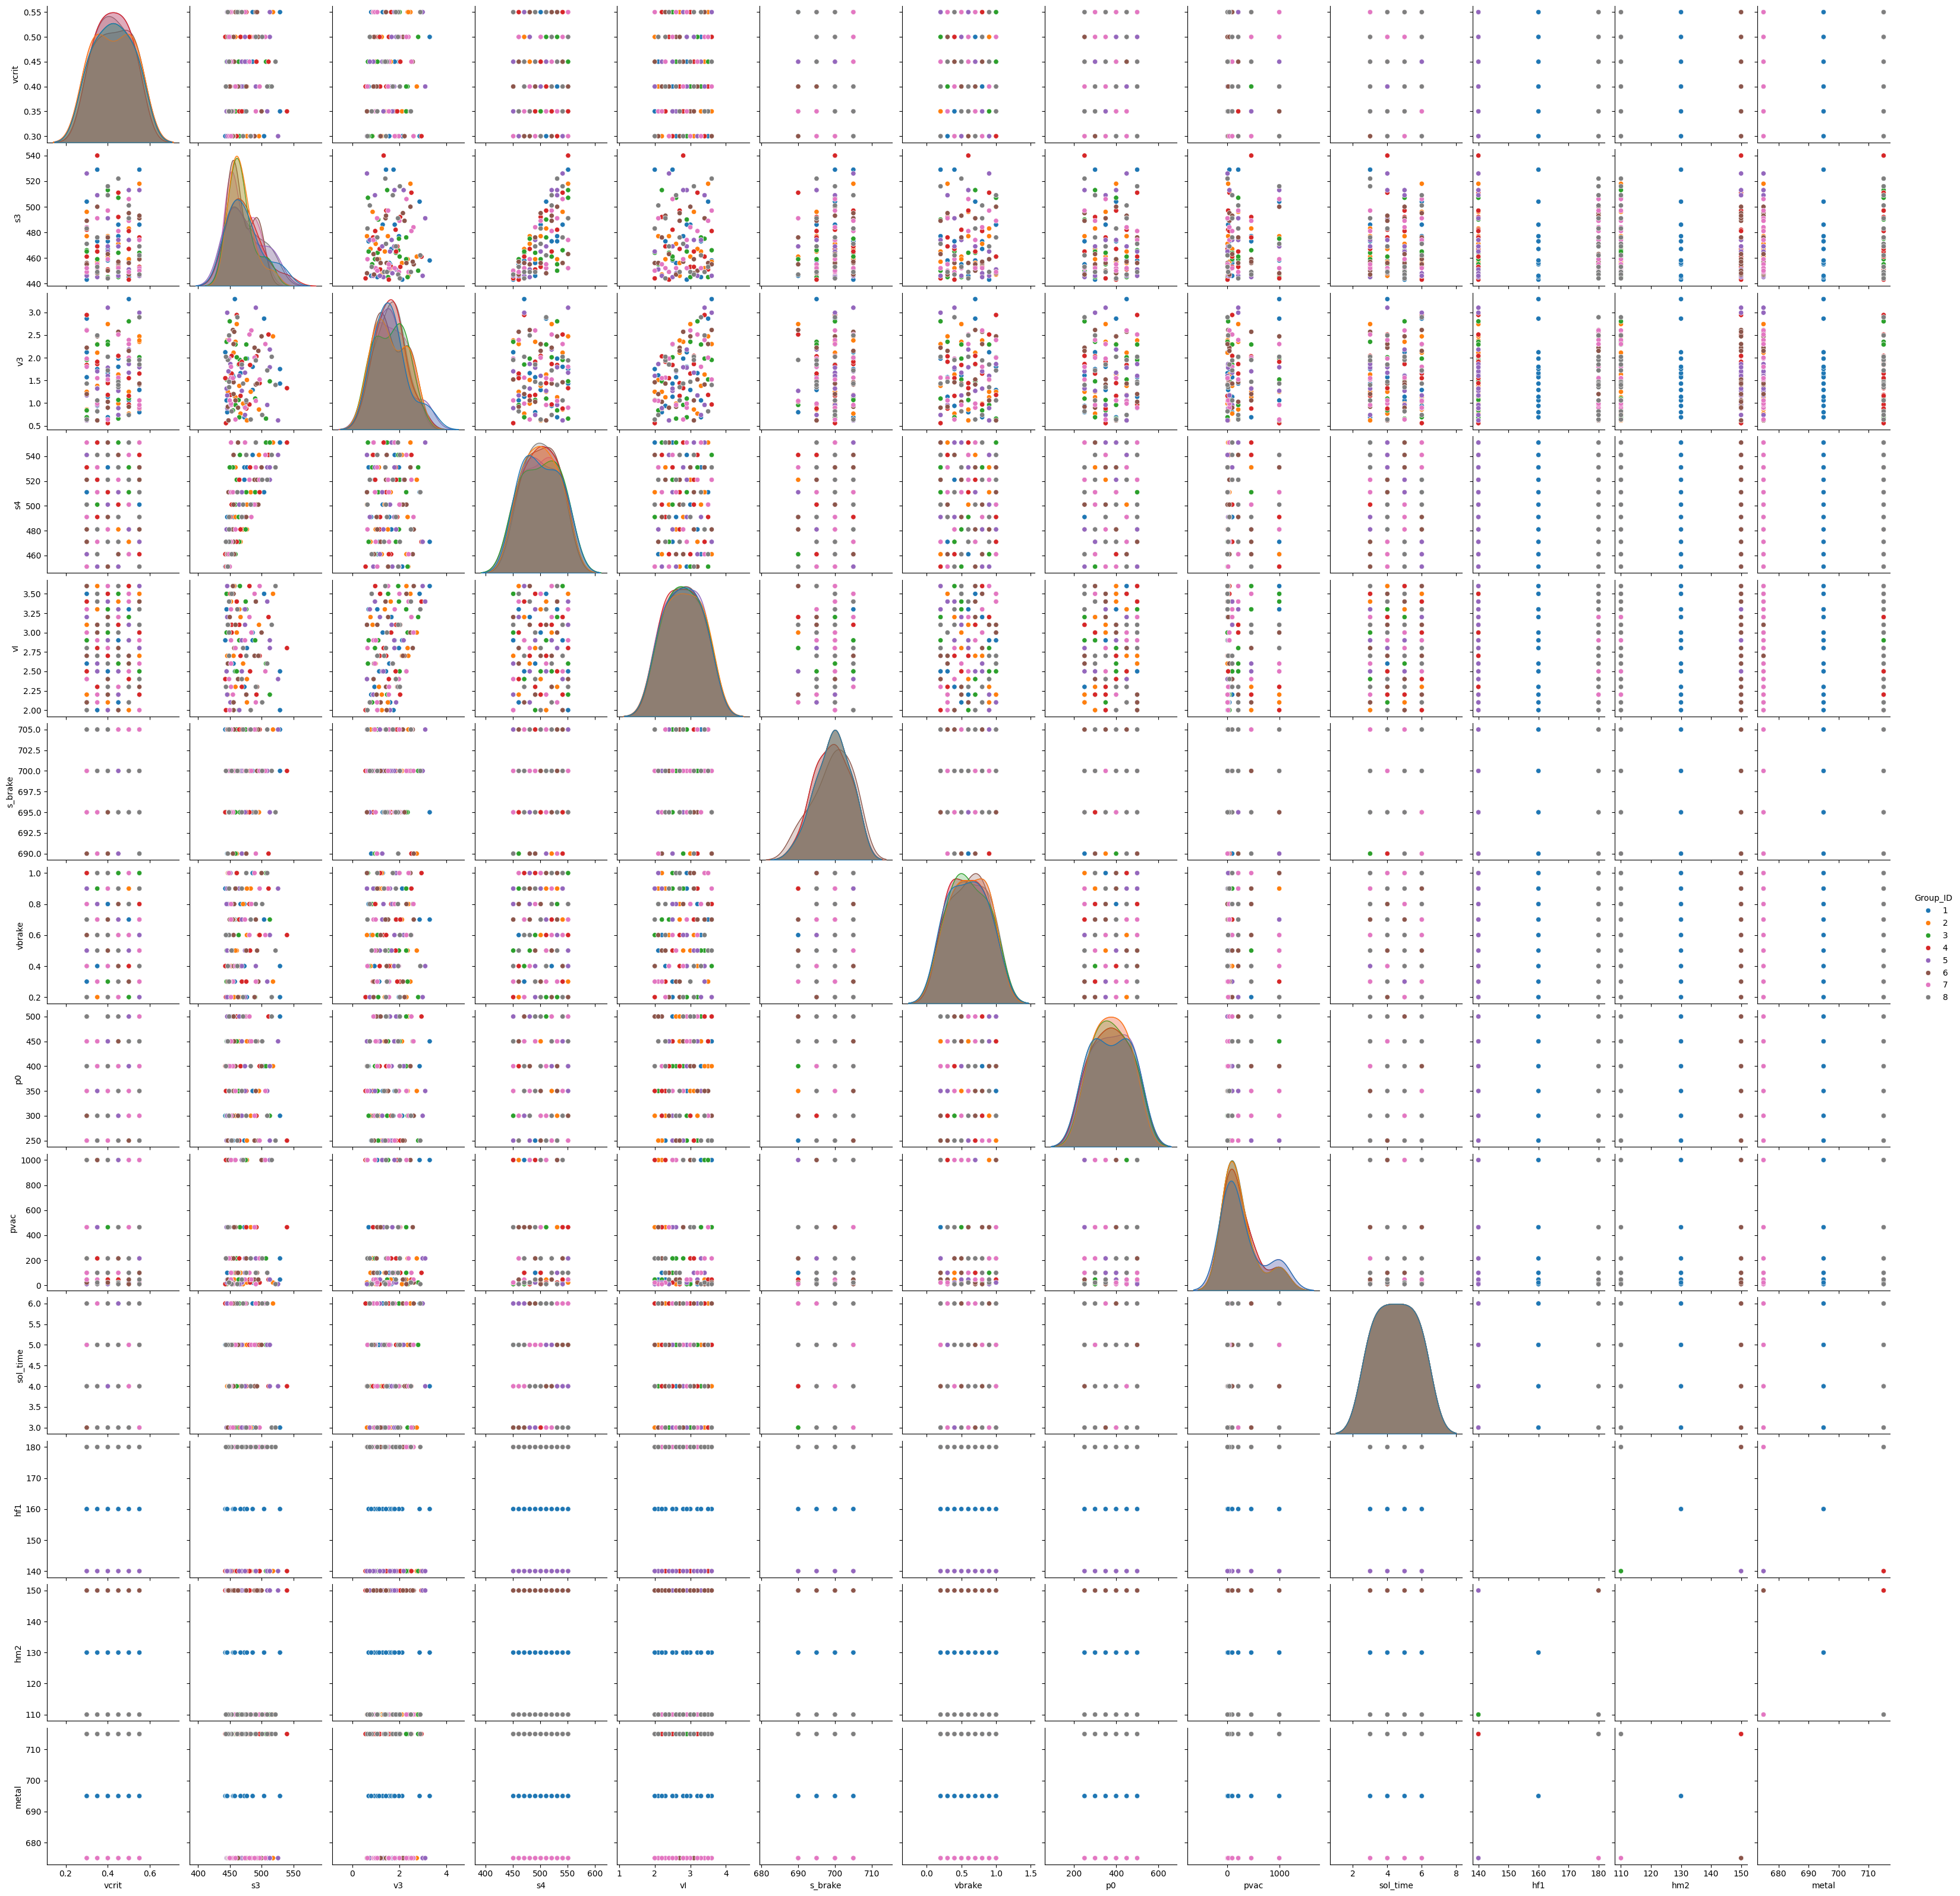

In [35]:
# plot
tmp = extended_doe.copy()
tmp["Group_ID"] = tmp["Group_ID"].astype(str)
sns.pairplot(tmp[columns2print[:8] + columns2print[9:15]], hue="Group_ID")
plt.savefig("dist.pdf")
plt.show()

In [36]:
# print to file
extended_doe.to_csv("test.csv", columns=columns2print, index_label="Parameter_set")